# 03_multiclass — Мультиклассовая классификация по типам окон атаки

**Цель ноутбука:**  
Обучить мультиклассовые классификаторы (CatBoostClassifier) для предсказания,  
в **каком временном окне** произойдёт ближайшая атака.

**Классы:**

| Класс | Метка | Описание |
|-------|-------|----------|
| 0 | `next_1d` | Атака завтра (≤1 день) — **критическая угроза** |
| 1 | `next_3d` | Атака в течение 2–3 дней — **высокая угроза** |
| 2 | `next_7d` | Атака в течение 4–7 дней — **средняя угроза** |
| 3 | `next_14d` | Атака в течение 8–14 дней — **низкая угроза** |
| 4 | `no_attack_30d` | Атаки не ожидается (> 14 дней или нет в горизонте) |

**Архитектура:**

```
dataset_features.parquet
        ↓
[Для каждого сегмента (infra × threat)]
        ↓
  Временной split (70% train / 15% val / 15% test)
        ↓
  CatBoostClassifier (multi_class, class_weights для дисбаланса)
        ↓
  Оценка: Macro F1, Weighted F1, Accuracy, per-class Recall
        ↓
  Сохранение моделей + метаданных
```

**Входные файлы:**
- `data/interim/dataset_features.parquet`
- `data/interim/feature_meta.json`

**Выходные файлы:**
- `mvp/models/multiclass/<infra>_<threat>.cbm`
- `mvp/models/results_multiclass.csv`


## 1. Установка зависимостей и импорты

In [1]:
!pip install catboost -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
from pathlib import Path

import catboost as cb
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

# Метки классов
ATTACK_WINDOW_LABELS = {
    0: 'next_1d',
    1: 'next_3d',
    2: 'next_7d',
    3: 'next_14d',
    4: 'no_attack_30d'
}
N_CLASSES = 5

print("Все библиотеки загружены")


Все библиотеки загружены


## 2. Загрузка данных

In [3]:
base_path = Path('..')
data_dir = base_path / 'data' / 'interim'

dataset_model = pd.read_parquet(data_dir / 'dataset_features.parquet')

with open(data_dir / 'feature_meta.json', 'r') as f:
    meta = json.load(f)

feature_cols = meta['feature_cols']
cat_features = meta['cat_features']
TARGET_COL = 'attack_window_class'

# Проверяем наличие целевой переменной
assert TARGET_COL in dataset_model.columns, (
    f"Столбец '{TARGET_COL}' не найден! "
    "Убедитесь, что 02_feature_engineering_v2.ipynb выполнен полностью."
)

print(f"Датасет: {dataset_model.shape}")
print(f"Признаков: {len(feature_cols)}")
print(f"\nРаспределение {TARGET_COL}:")
vc = dataset_model[TARGET_COL].value_counts().sort_index()
for cls, cnt in vc.items():
    pct = cnt / len(dataset_model) * 100
    print(f"  Класс {cls} ({ATTACK_WINDOW_LABELS.get(cls, '?')}): {cnt:>7,} ({pct:.1f}%)")


Датасет: (26112, 52)
Признаков: 20

Распределение attack_window_class:
  Класс 0 (next_1d):   3,579 (13.7%)
  Класс 1 (next_3d):   3,069 (11.8%)
  Класс 2 (next_7d):   4,880 (18.7%)
  Класс 3 (next_14d):   5,689 (21.8%)
  Класс 4 (no_attack_30d):   8,895 (34.1%)


## 3. EDA: распределение классов


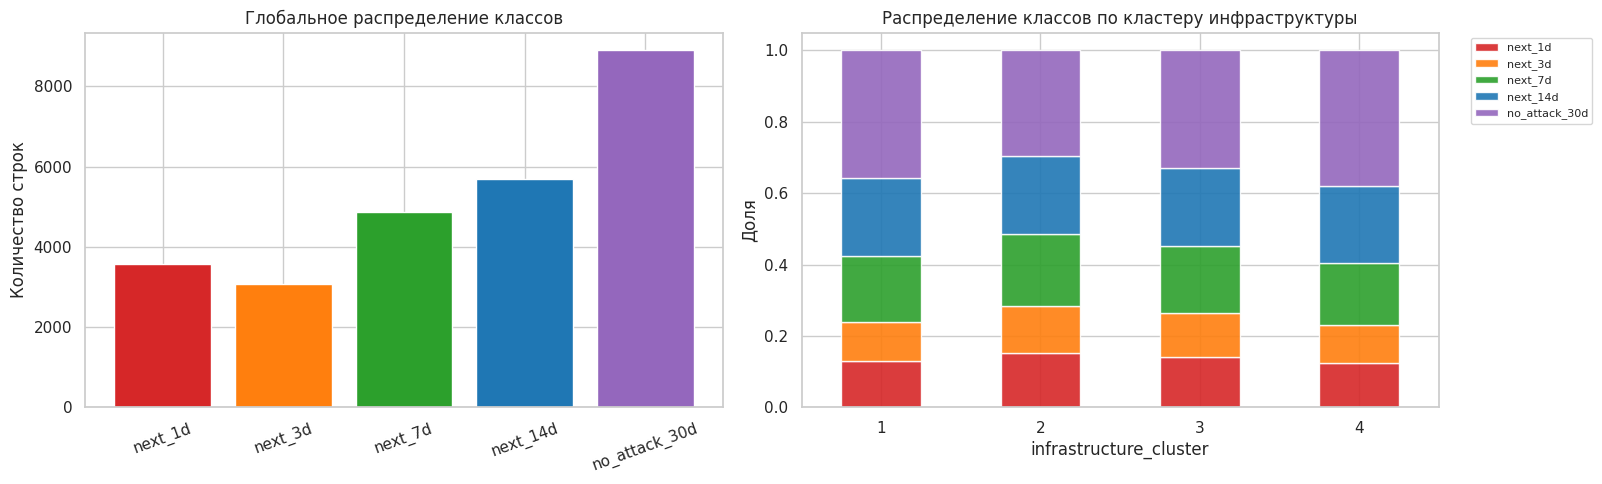


Коэффициент дисбаланса (max/min):
  2.9x


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Глобальное распределение
counts = dataset_model[TARGET_COL].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
labels = [ATTACK_WINDOW_LABELS[i] for i in range(N_CLASSES)]

axes[0].bar(labels, [counts.get(i, 0) for i in range(N_CLASSES)],
            color=colors, edgecolor='white')
axes[0].set_title('Глобальное распределение классов')
axes[0].set_ylabel('Количество строк')
axes[0].tick_params(axis='x', rotation=20)

# Распределение по кластерам инфраструктуры
pivot = dataset_model.groupby(['infrastructure_cluster', TARGET_COL]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='white', alpha=0.9)
axes[1].set_title('Распределение классов по кластеру инфраструктуры')
axes[1].set_ylabel('Доля')
axes[1].set_xlabel('infrastructure_cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend([ATTACK_WINDOW_LABELS[i] for i in range(N_CLASSES)],
               loc='upper right', fontsize=8, bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()

# Дисбаланс по классам
print("\nКоэффициент дисбаланса (max/min):")
print(f"  {counts.max() / counts.min():.1f}x")


## 4. Вспомогательные функции

### Стратегия работы с дисбалансом

Для мультиклассовых задач используем **`class_weights`** в CatBoost:
```python
class_weights = {cls: total / (n_classes * count) for cls, count in counts.items()}
```
Это стандартная `balanced`-стратегия: редкие классы получают больший вес.


In [5]:
def add_rolling(df_part: pd.DataFrame) -> pd.DataFrame:
    """Скользящие признаки (без data leakage)."""
    df_part = df_part.copy()
    grp = df_part.groupby(['infrastructure_cluster', 'threat_cluster'])

    for window, name in [(3, 'inc_3d_sum'), (7, 'inc_7d_sum'), (30, 'inc_30d_sum')]:
        df_part[name] = (
            grp['incidents_count_day'].shift(1)
            .rolling(window, min_periods=1).sum()
            .reset_index(drop=True).fillna(0)
        )
    for window, name in [(7, 'succ_7d_sum'), (30, 'succ_30d_sum')]:
        df_part[name] = (
            grp['success_count_day'].shift(1)
            .rolling(window, min_periods=1).sum()
            .reset_index(drop=True).fillna(0)
        )

    df_part['had_incident_prev_3d'] = (df_part['inc_3d_sum'] > 0).astype(int)
    df_part['had_incident_prev_7d'] = (df_part['inc_7d_sum'] > 0).astype(int)
    df_part['had_incident_prev_1d'] = (df_part.get('lag_inc_1d', pd.Series(0, index=df_part.index)) > 0).astype(int)

    return df_part


def compute_class_weights(y: np.ndarray, n_classes: int = N_CLASSES) -> dict:
    """
    Вычисляет веса классов по формуле balanced:
    weight_c = N_total / (n_classes × count_c)
    """
    total = len(y)
    weights = {}
    for cls in range(n_classes):
        count = (y == cls).sum()
        if count > 0:
            weights[cls] = total / (n_classes * count)
        else:
            weights[cls] = 1.0
    return weights


print("Функции add_rolling и compute_class_weights определены")


Функции add_rolling и compute_class_weights определены


## 5. Функция обучения мультиклассовых моделей по сегментам

### Ключевые параметры CatBoost для мультикласса:

| Параметр | Значение | Пояснение |
|---------|----------|-----------|
| `loss_function` | `'MultiClass'` | Softmax cross-entropy |
| `eval_metric` | `'TotalF1'` | Macro F1 по всем классам |
| `class_weights` | balanced | Компенсация дисбаланса |

### Метрики оценки:
- **Macro F1** — среднее F1 по всем классам (одинаково взвешены)
- **Weighted F1** — взвешенное по частоте классов
- **Per-class Recall** — критично для класса 0 (`next_1d`): не пропустить критическую угрозу


In [6]:
def train_multiclass_models_by_segments(
    data: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    cat_features: list,
    n_classes: int = N_CLASSES,
    min_rows: int = 120,
    min_classes: int = 3,
    verbose: bool = True
) -> tuple:
    """
    Обучает CatBoostClassifier (MultiClass) для каждого сегмента.

    Параметры:
    ----------
    data : pd.DataFrame
    feature_cols : list
    target_col : str         — 'attack_window_class'
    cat_features : list
    n_classes : int          — количество классов (5)
    min_rows : int           — минимум строк для сегмента
    min_classes : int        — минимум уникальных классов в train
    verbose : bool

    Возвращает:
    ----------
    models : dict {(infra, threat): CatBoostClassifier}
    results_df : pd.DataFrame
    """
    models = {}
    results = []

    infra_values = sorted(data['infrastructure_cluster'].astype(str).unique())
    threat_values = sorted(data['threat_cluster'].astype(int).unique())
    total = len(infra_values) * len(threat_values)
    done = 0

    for infra in infra_values:
        for threat in threat_values:
            done += 1
            part = data[
                (data['infrastructure_cluster'].astype(str) == str(infra)) &
                (data['threat_cluster'].astype(int) == int(threat))
            ].copy()

            if len(part) < min_rows:
                if verbose:
                    print(f"  [{done}/{total}] infra={infra} threat={threat} — пропуск (<{min_rows} строк)")
                continue

            # Временной split 70/15/15
            part = part.sort_values('date').reset_index(drop=True)
            unique_dates = np.array(sorted(part['date'].unique()))
            n = len(unique_dates)
            if n < 30:
                continue

            train_end = int(n * 0.70)
            val_end   = int(n * 0.85)

            train_dates = unique_dates[:train_end]
            val_dates   = unique_dates[train_end:val_end]
            test_dates  = unique_dates[val_end:]

            train_df = add_rolling(part[part['date'].isin(train_dates)].copy())
            val_df   = add_rolling(part[part['date'].isin(val_dates)].copy())
            test_df  = add_rolling(part[part['date'].isin(test_dates)].copy())

            # Проверяем количество уникальных классов
            n_unique = train_df[target_col].nunique()
            if n_unique < min_classes:
                if verbose:
                    print(f"  [{done}/{total}] infra={infra} threat={threat} — пропуск (только {n_unique} классов в train)")
                continue

            # Подготовка признаков
            local_cats = [c for c in cat_features if c in feature_cols]
            avail_feats = [f for f in feature_cols if f in train_df.columns]

            def prep(df):
                X = df[avail_feats].copy()
                for c in local_cats:
                    if c in X.columns:
                        X[c] = X[c].astype(str)
                return X

            X_train = prep(train_df)
            X_val   = prep(val_df)
            X_test  = prep(test_df)

            y_train = train_df[target_col].values.astype(int)
            y_val   = val_df[target_col].values.astype(int)
            y_test  = test_df[target_col].values.astype(int)

            # Веса классов (balanced)
            class_weights = compute_class_weights(y_train, n_classes=n_classes)

            train_pool = cb.Pool(X_train, y_train, cat_features=local_cats)
            val_pool   = cb.Pool(X_val,   y_val,   cat_features=local_cats)

            model = cb.CatBoostClassifier(
                iterations=600,
                learning_rate=0.05,
                depth=6,
                loss_function='MultiClass',
                eval_metric='TotalF1',
                early_stopping_rounds=60,
                class_weights=class_weights,
                random_seed=42,
                verbose=0,
                allow_writing_files=False
            )

            model.fit(train_pool, eval_set=val_pool, use_best_model=True)

            # Метрики
            def get_metrics(y_true, y_pred, prefix):
                macro_f1  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
                weight_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
                acc       = accuracy_score(y_true, y_pred)

                # per-class recall (особенно важен класс 0)
                per_class = {}
                for cls in range(n_classes):
                    mask = y_true == cls
                    if mask.sum() > 0:
                        recall_c = (y_pred[mask] == cls).mean()
                    else:
                        recall_c = np.nan
                    per_class[f'{prefix}_recall_cls{cls}'] = recall_c

                return {
                    f'{prefix}_macro_f1':   macro_f1,
                    f'{prefix}_weighted_f1': weight_f1,
                    f'{prefix}_accuracy':   acc,
                    **per_class
                }

            val_pred  = model.predict(X_val).flatten().astype(int)
            test_pred = model.predict(X_test).flatten().astype(int)

            m_val  = get_metrics(y_val,  val_pred,  'val')
            m_test = get_metrics(y_test, test_pred, 'test')

            row = {
                'infrastructure_cluster': str(infra),
                'threat_cluster': int(threat),
                'n_train': len(train_df),
                'n_val':   len(val_df),
                'n_test':  len(test_df),
                'n_unique_classes_train': n_unique,
                **m_val,
                **m_test
            }
            results.append(row)
            models[(str(infra), int(threat))] = model

            if verbose:
                print(f"  [{done}/{total}] infra={infra} threat={threat} | "
                      f"val F1={m_val['val_macro_f1']:.3f} | "
                      f"test F1={m_test['test_macro_f1']:.3f} | "
                      f"acc={m_test['test_accuracy']:.3f}")

    return models, pd.DataFrame(results)


print("Функция train_multiclass_models_by_segments определена")


Функция train_multiclass_models_by_segments определена


## 6. Обучение мультиклассовых моделей

Предсказываем: **в каком временном окне ожидается ближайшая атака?**

Классы упорядочены по срочности — от «атака завтра» до «нет угрозы в 30-дневном горизонте».


In [7]:
print("Обучение мультиклассовых моделей (attack_window_class)...")
print(f"Сегментов для обхода: "
      f"{dataset_model['infrastructure_cluster'].nunique()} × "
      f"{dataset_model['threat_cluster'].nunique()}")

models_mc, results_mc = train_multiclass_models_by_segments(
    data=dataset_model,
    feature_cols=feature_cols,
    target_col=TARGET_COL,
    cat_features=cat_features,
    n_classes=N_CLASSES,
    min_rows=120,
    min_classes=3,
    verbose=True
)

print(f"\n{'='*80}")
print(f"Обучено моделей: {len(models_mc)}")
print(f"\nТаблица результатов (по убыванию Macro F1):")
display(results_mc.sort_values('test_macro_f1', ascending=False).round(4))


Обучение мультиклассовых моделей (attack_window_class)...
Сегментов для обхода: 4 × 6
  [1/24] infra=1 threat=1 | val F1=0.841 | test F1=0.809 | acc=0.823
  [2/24] infra=1 threat=2 | val F1=0.801 | test F1=0.857 | acc=0.872
  [3/24] infra=1 threat=3 | val F1=0.824 | test F1=0.824 | acc=0.829
  [4/24] infra=1 threat=4 | val F1=0.856 | test F1=0.822 | acc=0.841
  [5/24] infra=1 threat=5 | val F1=0.820 | test F1=0.848 | acc=0.848
  [6/24] infra=1 threat=6 | val F1=0.894 | test F1=0.824 | acc=0.811
  [7/24] infra=2 threat=1 | val F1=0.818 | test F1=0.812 | acc=0.793
  [8/24] infra=2 threat=2 | val F1=0.830 | test F1=0.820 | acc=0.829
  [9/24] infra=2 threat=3 | val F1=0.822 | test F1=0.785 | acc=0.774
  [10/24] infra=2 threat=4 | val F1=0.808 | test F1=0.803 | acc=0.799
  [11/24] infra=2 threat=5 | val F1=0.824 | test F1=0.806 | acc=0.799
  [12/24] infra=2 threat=6 | val F1=0.839 | test F1=0.826 | acc=0.835
  [13/24] infra=3 threat=1 | val F1=0.875 | test F1=0.831 | acc=0.817
  [14/24] inf

,infrastructure_cluster,threat_cluster,n_train,n_val,n_test,n_unique_classes_train,val_macro_f1,val_weighted_f1,val_accuracy,val_recall_cls0,...,val_recall_cls3,val_recall_cls4,test_macro_f1,test_weighted_f1,test_accuracy,test_recall_cls0,test_recall_cls1,test_recall_cls2,test_recall_cls3,test_recall_cls4
15,3,4,761,163,164,5,0.8175,0.8329,0.8160,1.0,...,0.8846,0.8475,0.8951,0.9065,0.8902,1.0000,1.0000,1.0000,0.9429,0.8118
22,4,5,761,163,164,5,0.8155,0.8276,0.8098,1.0,...,1.0000,0.8269,0.8872,0.9383,0.9268,1.0000,0.7500,1.0000,1.0000,0.9115
17,3,6,761,163,164,5,0.7742,0.7788,0.7546,1.0,...,0.6047,0.6667,0.8627,0.8716,0.8537,1.0000,0.8750,0.8571,0.9000,0.7586
1,1,2,761,163,164,5,0.8010,0.8017,0.7791,1.0,...,0.7429,0.6250,0.8573,0.8903,0.8720,1.0000,0.8000,0.8750,0.8125,0.8800
23,4,6,761,163,164,5,0.8036,0.8210,0.7975,1.0,...,0.6667,0.8696,0.8509,0.8819,0.8598,1.0000,0.8571,0.8696,0.7931,0.8519
21,4,4,761,163,164,5,0.8124,0.8160,0.7975,1.0,...,0.8205,0.5625,0.8490,0.8578,0.8415,1.0000,0.8824,0.9333,0.9149,0.6400
4,1,5,761,163,164,5,0.8205,0.8258,0.8037,1.0,...,0.8462,0.6522,0.8477,0.8703,0.8476,1.0000,0.8235,0.9655,0.7727,0.8036
12,3,1,761,163,164,5,0.8748,0.9590,0.9509,1.0,...,1.0000,0.9492,0.8309,0.8422,0.8171,1.0000,0.8500,0.8065,0.8462,0.7115
11,2,6,761,163,164,5,0.8389,0.8769,0.8528,1.0,...,0.7429,0.8767,0.8258,0.8560,0.8354,1.0000,0.8333,0.6207,0.8400,0.8732
2,1,3,761,163,164,5,0.8240,0.8366,0.8098,1.0,...,0.6667,0.7805,0.8244,0.8458,0.8293,0.9091,0.7647,0.8621,0.8286,0.8033


In [16]:
models_mc

{('1', 1): <catboost.core.CatBoostClassifier at 0x796e34610d90>,
 ('1', 2): <catboost.core.CatBoostClassifier at 0x796e345c8550>,
 ('1', 3): <catboost.core.CatBoostClassifier at 0x796e34552590>,
 ('1', 4): <catboost.core.CatBoostClassifier at 0x796e3454d910>,
 ('1', 5): <catboost.core.CatBoostClassifier at 0x796e3443e790>,
 ('1', 6): <catboost.core.CatBoostClassifier at 0x796e773e8b90>,
 ('2', 1): <catboost.core.CatBoostClassifier at 0x796e3459d610>,
 ('2', 2): <catboost.core.CatBoostClassifier at 0x796e345a8ad0>,
 ('2', 3): <catboost.core.CatBoostClassifier at 0x796e34597d50>,
 ('2', 4): <catboost.core.CatBoostClassifier at 0x796e34711390>,
 ('2', 5): <catboost.core.CatBoostClassifier at 0x796e345a8e10>,
 ('2', 6): <catboost.core.CatBoostClassifier at 0x796e7740be50>,
 ('3', 1): <catboost.core.CatBoostClassifier at 0x796e34445190>,
 ('3', 2): <catboost.core.CatBoostClassifier at 0x796e77385010>,
 ('3', 3): <catboost.core.CatBoostClassifier at 0x796e345a68d0>,
 ('3', 4): <catboost.core

## 7. Анализ результатов

### Интерпретация метрик

| Метрика | Значение |
|---------|----------|
| **Macro F1** | Среднее F1 по всем классам. Строгая метрика — чувствительна к редким классам |
| **Weighted F1** | F1, взвешенный по частоте классов. Ближе к общей точности |
| **Accuracy** | Доля правильных ответов. Не показательна при дисбалансе |
| **Recall класса 0** | Доля угроз «следующего дня», которые модель поймала. **Ключевая метрика!** |

Для задачи ИБ: **Recall класса 0 ≥ 0.7** — приоритет, даже ценой большего числа ложных тревог.


=== Сводная статистика метрик ===

test_macro_f1: mean=0.826, median=0.821, min=0.783, max=0.895
test_weighted_f1: mean=0.846, median=0.844, min=0.794, max=0.938
test_accuracy: mean=0.825, median=0.820, min=0.774, max=0.927
test_recall_cls0: mean=0.996, median=1.000, min=0.909, max=1.000
test_recall_cls4: mean=0.774, median=0.803, min=0.519, max=0.912


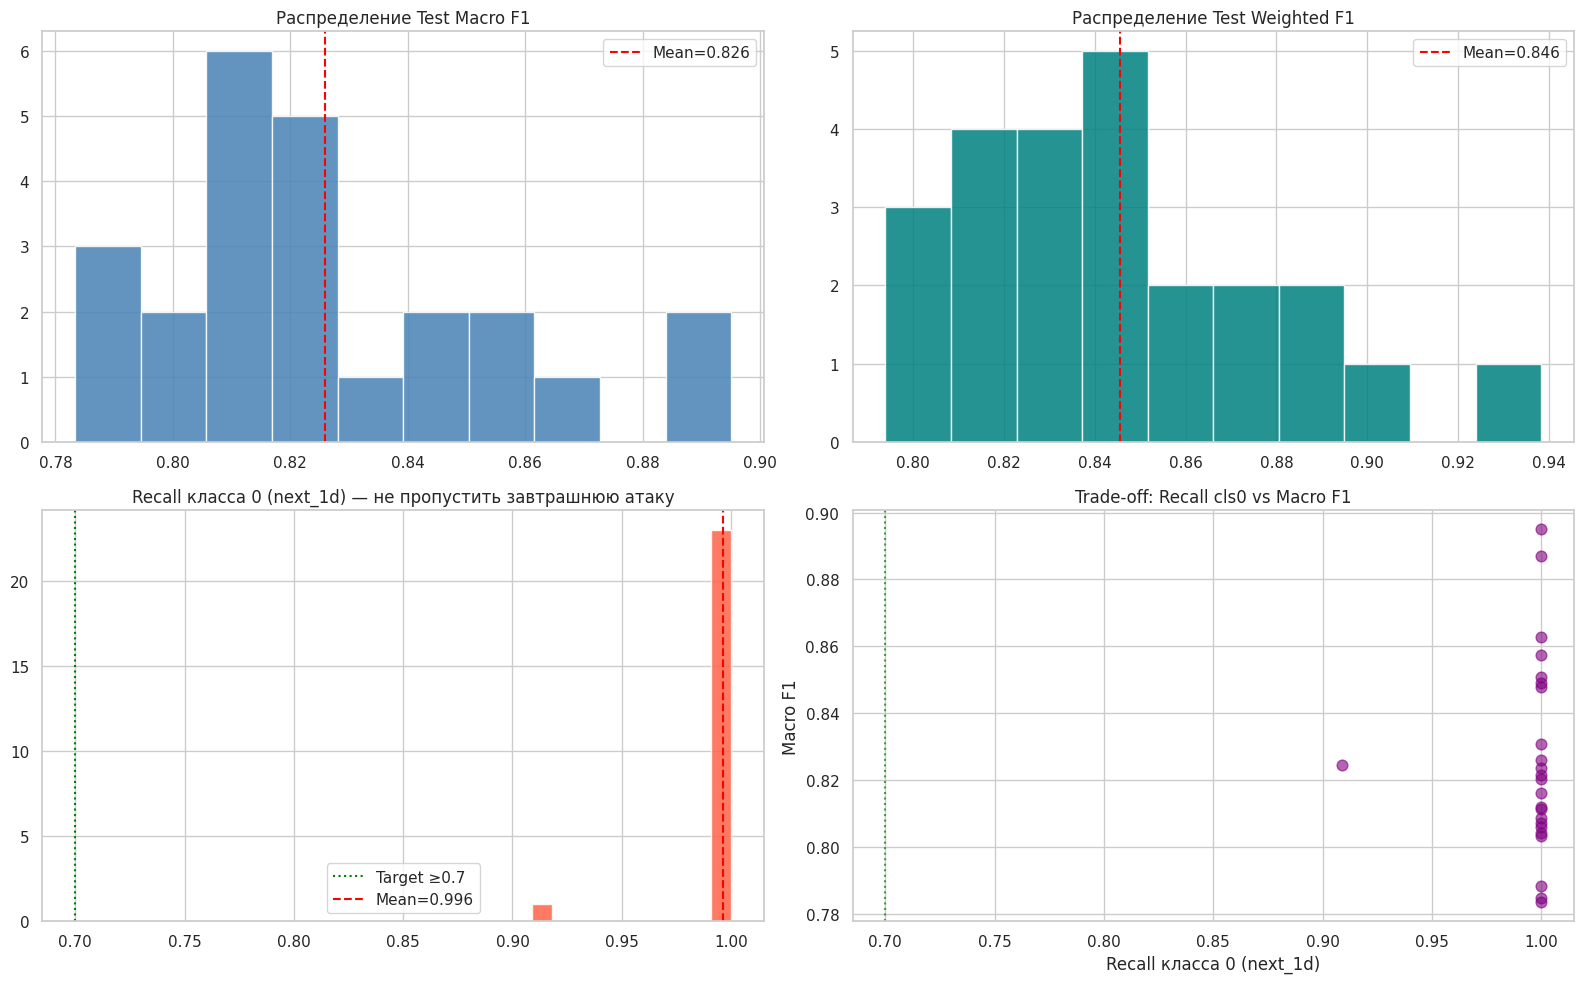

In [8]:
if len(results_mc) == 0:
    print("Нет обученных моделей — проверьте данные")
else:
    print("=== Сводная статистика метрик ===\n")
    for m in ['test_macro_f1', 'test_weighted_f1', 'test_accuracy',
              'test_recall_cls0', 'test_recall_cls4']:
        s = results_mc[m].dropna()
        if len(s) > 0:
            print(f"{m}: mean={s.mean():.3f}, median={s.median():.3f}, "
                  f"min={s.min():.3f}, max={s.max():.3f}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Macro F1
    axes[0,0].hist(results_mc['test_macro_f1'].dropna(), bins=10,
                   color='steelblue', edgecolor='white', alpha=0.85)
    axes[0,0].axvline(results_mc['test_macro_f1'].mean(), color='red',
                      linestyle='--', label=f"Mean={results_mc['test_macro_f1'].mean():.3f}")
    axes[0,0].set_title('Распределение Test Macro F1')
    axes[0,0].legend()

    # Weighted F1
    axes[0,1].hist(results_mc['test_weighted_f1'].dropna(), bins=10,
                   color='teal', edgecolor='white', alpha=0.85)
    axes[0,1].axvline(results_mc['test_weighted_f1'].mean(), color='red',
                      linestyle='--', label=f"Mean={results_mc['test_weighted_f1'].mean():.3f}")
    axes[0,1].set_title('Распределение Test Weighted F1')
    axes[0,1].legend()

    # Recall класса 0 (next_1d) — критически важный
    if 'test_recall_cls0' in results_mc.columns:
        axes[1,0].hist(results_mc['test_recall_cls0'].dropna(), bins=10,
                       color='tomato', edgecolor='white', alpha=0.85)
        axes[1,0].axvline(0.7, color='green', linestyle=':', label='Target ≥0.7')
        mean_r0 = results_mc['test_recall_cls0'].mean()
        axes[1,0].axvline(mean_r0, color='red',
                          linestyle='--', label=f"Mean={mean_r0:.3f}")
        axes[1,0].set_title('Recall класса 0 (next_1d) — не пропустить завтрашнюю атаку')
        axes[1,0].legend()

    # Scatter Macro F1 vs Recall cls0
    if 'test_recall_cls0' in results_mc.columns:
        axes[1,1].scatter(results_mc['test_recall_cls0'],
                          results_mc['test_macro_f1'],
                          alpha=0.6, color='purple', s=60)
        axes[1,1].axvline(0.7, color='green', linestyle=':', alpha=0.7)
        axes[1,1].set_xlabel('Recall класса 0 (next_1d)')
        axes[1,1].set_ylabel('Macro F1')
        axes[1,1].set_title('Trade-off: Recall cls0 vs Macro F1')

    plt.tight_layout()
    plt.show()


## 8. Confusion Matrix лучшего сегмента

Сегмент: infra=3, threat=4
Test Macro F1: 0.8951



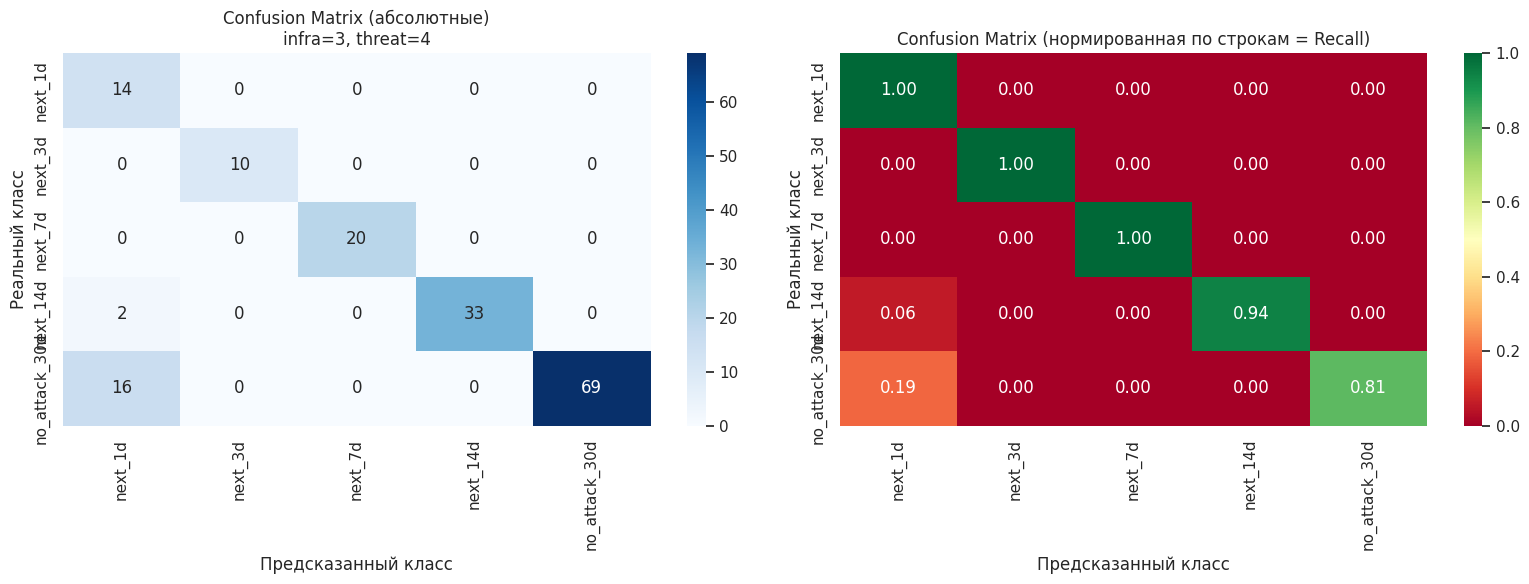


Classification Report:
               precision    recall  f1-score   support

      next_1d       0.44      1.00      0.61        14
      next_3d       1.00      1.00      1.00        10
      next_7d       1.00      1.00      1.00        20
     next_14d       1.00      0.94      0.97        35
no_attack_30d       1.00      0.81      0.90        85

     accuracy                           0.89       164
    macro avg       0.89      0.95      0.90       164
 weighted avg       0.95      0.89      0.91       164



In [9]:
if len(results_mc) > 0:
    best_row = results_mc.loc[results_mc['test_macro_f1'].idxmax()]
    infra_v  = str(best_row['infrastructure_cluster'])
    threat_v = int(best_row['threat_cluster'])

    part = dataset_model[
        (dataset_model['infrastructure_cluster'].astype(str) == infra_v) &
        (dataset_model['threat_cluster'].astype(int) == threat_v)
    ].copy().sort_values('date').reset_index(drop=True)

    unique_dates = np.array(sorted(part['date'].unique()))
    n = len(unique_dates)
    test_dates = unique_dates[int(n * 0.85):]

    test_df = add_rolling(part[part['date'].isin(test_dates)].copy())
    avail_feats = [f for f in feature_cols if f in test_df.columns]
    X_test = test_df[avail_feats].copy()
    local_cats = [c for c in cat_features if c in X_test.columns]
    for c in local_cats:
        X_test[c] = X_test[c].astype(str)

    model = models_mc[(infra_v, threat_v)]
    y_pred = model.predict(X_test).flatten().astype(int)
    y_true = test_df[TARGET_COL].values.astype(int)

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"Сегмент: infra={infra_v}, threat={threat_v}")
    print(f"Test Macro F1: {macro_f1:.4f}\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Абсолютные значения
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=list(ATTACK_WINDOW_LABELS.values()),
                yticklabels=list(ATTACK_WINDOW_LABELS.values()))
    axes[0].set_title(f'Confusion Matrix (абсолютные)\ninfra={infra_v}, threat={threat_v}')
    axes[0].set_ylabel('Реальный класс')
    axes[0].set_xlabel('Предсказанный класс')

    # Нормированные по строкам (Recall по классам)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
                vmin=0, vmax=1,
                xticklabels=list(ATTACK_WINDOW_LABELS.values()),
                yticklabels=list(ATTACK_WINDOW_LABELS.values()))
    axes[1].set_title('Confusion Matrix (нормированная по строкам = Recall)')
    axes[1].set_ylabel('Реальный класс')
    axes[1].set_xlabel('Предсказанный класс')

    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        labels=list(range(N_CLASSES)),
        target_names=list(ATTACK_WINDOW_LABELS.values()),
        zero_division=0
    ))


## 9. Heatmap Macro F1 по сегментам

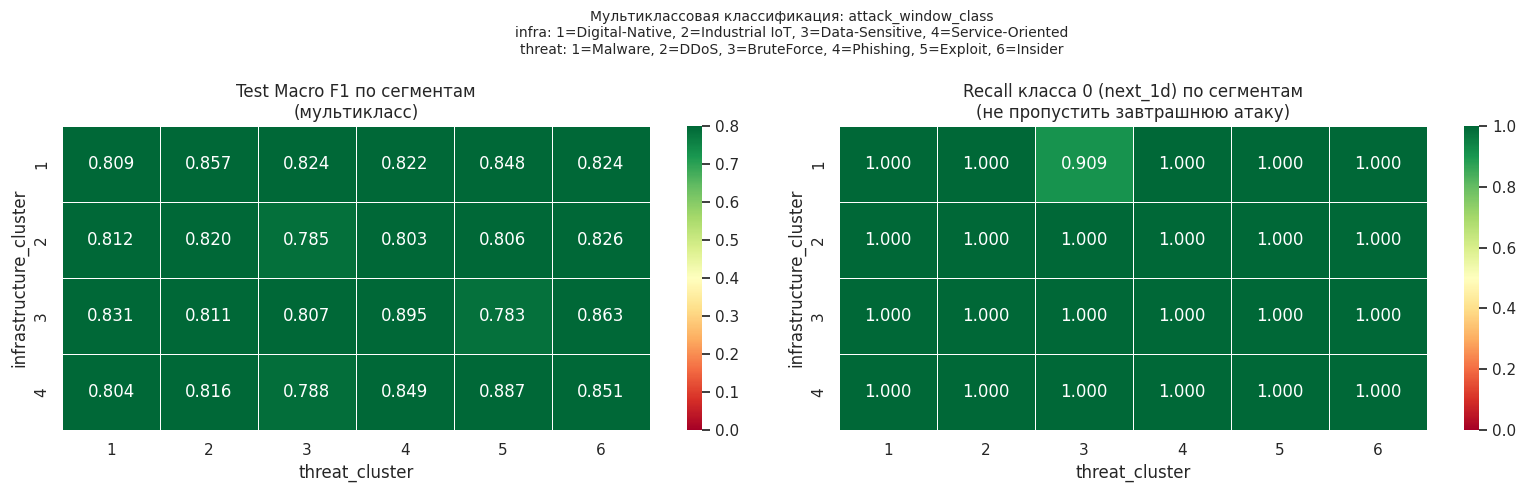

In [10]:
if len(results_mc) > 0:
    pivot_f1 = results_mc.pivot(
        index='infrastructure_cluster',
        columns='threat_cluster',
        values='test_macro_f1'
    )

    pivot_r0 = results_mc.pivot(
        index='infrastructure_cluster',
        columns='threat_cluster',
        values='test_recall_cls0'
    ) if 'test_recall_cls0' in results_mc.columns else None

    n_plots = 2 if pivot_r0 is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=0.8, ax=axes[0],
                linewidths=0.5, mask=pivot_f1.isna())
    axes[0].set_title('Test Macro F1 по сегментам\n(мультикласс)')

    if pivot_r0 is not None:
        sns.heatmap(pivot_r0, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=0, vmax=1.0, ax=axes[1],
                    linewidths=0.5, mask=pivot_r0.isna())
        axes[1].set_title('Recall класса 0 (next_1d) по сегментам\n(не пропустить завтрашнюю атаку)')

    plt.suptitle('Мультиклассовая классификация: attack_window_class\n'
                 'infra: 1=Digital-Native, 2=Industrial IoT, 3=Data-Sensitive, 4=Service-Oriented\n'
                 'threat: 1=Malware, 2=DDoS, 3=BruteForce, 4=Phishing, 5=Exploit, 6=Insider',
                 fontsize=10)
    plt.tight_layout()
    plt.show()


## 10. Важность признаков

Feature Importance (infra=1, threat=1):


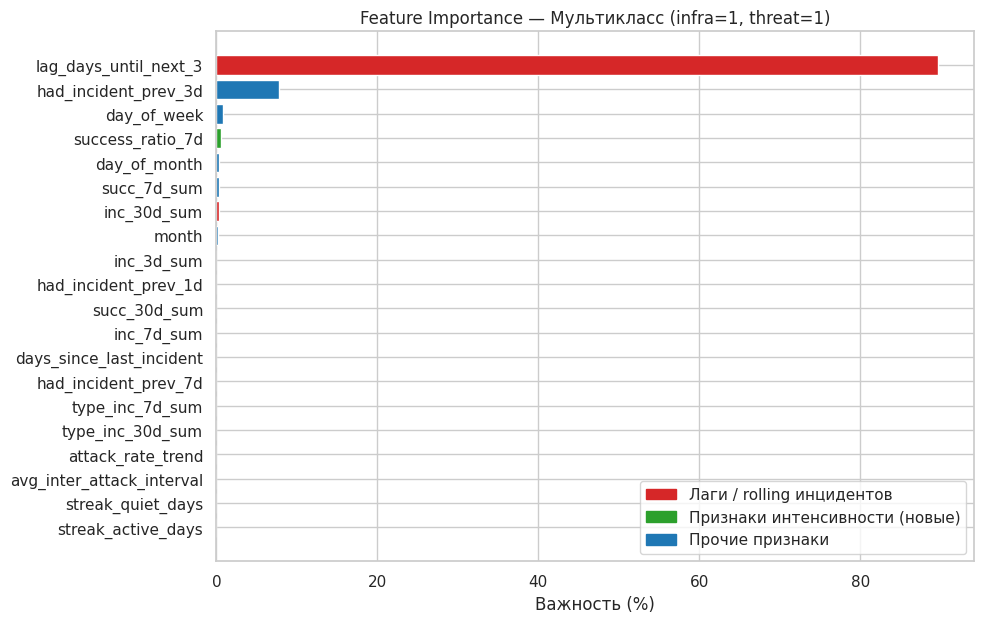


Топ-10 признаков:


,feature,importance
19,lag_days_until_next_3,89.648141
9,had_incident_prev_3d,7.773554
0,day_of_week,0.761318
18,success_ratio_7d,0.542569
1,day_of_month,0.368433
6,succ_7d_sum,0.336946
5,inc_30d_sum,0.333941
2,month,0.235096
3,inc_3d_sum,0.000000
8,had_incident_prev_1d,0.000000


In [11]:
if models_mc:
    sample_key = list(models_mc.keys())[0]
    model = models_mc[sample_key]

    importance_df = pd.DataFrame({
        'feature': model.feature_names_,
        'importance': model.get_feature_importance()
    }).sort_values('importance', ascending=False)

    print(f"Feature Importance (infra={sample_key[0]}, threat={sample_key[1]}):")

    fig, ax = plt.subplots(figsize=(10, max(6, len(importance_df) * 0.32)))
    colors = ['#d62728' if any(kw in f for kw in ['inc_', 'days_since', 'streak', 'lag_days'])
              else '#2ca02c' if any(kw in f for kw in ['attack_rate', 'success_ratio', 'avg_inter'])
              else '#1f77b4'
              for f in importance_df['feature']]
    ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance — Мультикласс (infra={sample_key[0]}, threat={sample_key[1]})')
    ax.set_xlabel('Важность (%)')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(color='#d62728', label='Лаги / rolling инцидентов'),
        Patch(color='#2ca02c', label='Признаки интенсивности (новые)'),
        Patch(color='#1f77b4', label='Прочие признаки'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()

    print("\nТоп-10 признаков:")
    display(importance_df.head(10))


## 11. Вероятности по классам (вместо жёсткого предсказания)

Вместо одного класса модель возвращает распределение вероятностей по всем 5 классам.
Это позволяет реализовать более тонкое управление оповещениями:
- P(class=0) > 0.4 → немедленная тревога
- P(class=0) + P(class=1) > 0.6 → повышенная готовность


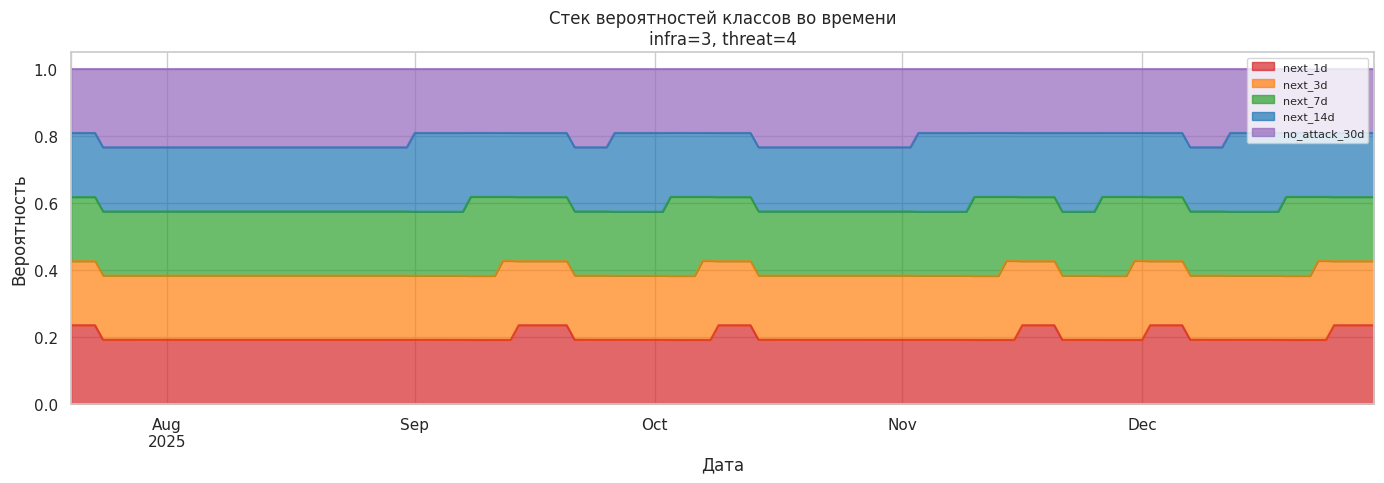


Пример: первые 5 предсказаний с вероятностями:


,next_1d,next_3d,next_7d,next_14d,no_attack_30d,predicted_class,predicted_label
2025-07-20,0.235,0.191,0.191,0.191,0.191,0,next_1d
2025-07-21,0.235,0.191,0.191,0.191,0.191,0,next_1d
2025-07-22,0.235,0.191,0.191,0.191,0.191,0,next_1d
2025-07-23,0.235,0.191,0.191,0.191,0.191,0,next_1d
2025-07-24,0.192,0.192,0.192,0.192,0.234,4,no_attack_30d


In [12]:
if len(results_mc) > 0:
    best_row  = results_mc.loc[results_mc['test_macro_f1'].idxmax()]
    infra_v   = str(best_row['infrastructure_cluster'])
    threat_v  = int(best_row['threat_cluster'])
    model     = models_mc[(infra_v, threat_v)]

    part = dataset_model[
        (dataset_model['infrastructure_cluster'].astype(str) == infra_v) &
        (dataset_model['threat_cluster'].astype(int) == threat_v)
    ].copy().sort_values('date').reset_index(drop=True)

    unique_dates = np.array(sorted(part['date'].unique()))
    n = len(unique_dates)
    test_dates = unique_dates[int(n * 0.85):]
    test_df = add_rolling(part[part['date'].isin(test_dates)].copy())

    avail_feats = [f for f in feature_cols if f in test_df.columns]
    X_test = test_df[avail_feats].copy()
    for c in [c for c in cat_features if c in X_test.columns]:
        X_test[c] = X_test[c].astype(str)

    proba = model.predict_proba(X_test)  # shape: (n_rows, 5)

    # Строим стековый area-chart вероятностей во времени
    proba_df = pd.DataFrame(
        proba,
        columns=[ATTACK_WINDOW_LABELS[i] for i in range(N_CLASSES)],
        index=test_df['date'].values
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    proba_df.plot.area(ax=ax, alpha=0.7, color=['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd'])
    ax.set_title(f'Стек вероятностей классов во времени\ninfra={infra_v}, threat={threat_v}')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Вероятность')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nПример: первые 5 предсказаний с вероятностями:")
    sample = proba_df.head(5).round(3)
    sample['predicted_class'] = model.predict(X_test.head(5)).flatten().astype(int)
    sample['predicted_label'] = sample['predicted_class'].map(ATTACK_WINDOW_LABELS)
    display(sample)


In [15]:
proba_df

,next_1d,next_3d,next_7d,next_14d,no_attack_30d
2025-07-20,0.234835,0.191291,0.191291,0.191291,0.191291
2025-07-21,0.234835,0.191291,0.191291,0.191291,0.191291
2025-07-22,0.234835,0.191291,0.191291,0.191291,0.191291
2025-07-23,0.234835,0.191291,0.191291,0.191291,0.191291
2025-07-24,0.191516,0.191516,0.191516,0.191516,0.233935
...,...,...,...,...,...
2025-12-26,0.234835,0.191291,0.191291,0.191291,0.191291
2025-12-27,0.234835,0.191291,0.191291,0.191291,0.191291
2025-12-28,0.234835,0.191291,0.191291,0.191291,0.191291
2025-12-29,0.234835,0.191291,0.191291,0.191291,0.191291


## 12. Сохранение моделей

In [13]:
PROJECT_ROOT = Path('.').resolve()
MVP_DIR  = PROJECT_ROOT / 'mvp'
MC_DIR   = MVP_DIR / 'models' / 'multiclass'
MC_DIR.mkdir(parents=True, exist_ok=True)

for (infra, threat), model in models_mc.items():
    model.save_model(str(MC_DIR / f"{infra}_{threat}.cbm"))

print(f"Сохранено мультиклассовых моделей: {len(models_mc)} → {MC_DIR}")

results_mc.to_csv(MVP_DIR / 'models' / 'results_multiclass.csv', index=False)
print(f"Таблица результатов: {MVP_DIR / 'models' / 'results_multiclass.csv'}")

# Метаданные
import json as json_mod
mc_meta = {
    'task': 'multiclass_classification',
    'target_col': TARGET_COL,
    'n_classes': N_CLASSES,
    'class_labels': ATTACK_WINDOW_LABELS,
    'feature_cols': feature_cols,
    'cat_features': cat_features,
    'models': [f"{k[0]}_{k[1]}" for k in models_mc.keys()]
}
with open(MVP_DIR / 'models' / 'multiclass_meta.json', 'w') as f:
    json_mod.dump(mc_meta, f, ensure_ascii=False, indent=2)

print("Метаданные: multiclass_meta.json")


Сохранено мультиклассовых моделей: 24 → /home/max/projects/rsm_hackathon_2026/notebooks/mvp/models/multiclass
Таблица результатов: /home/max/projects/rsm_hackathon_2026/notebooks/mvp/models/results_multiclass.csv
Метаданные: multiclass_meta.json


## 13. Утилита инференса

In [14]:
def predict_attack_window(
    infra_cluster: int,
    threat_cluster: int,
    feature_values: dict,
    models_dir: Path = Path('mvp/models')
) -> dict:
    """
    Предсказать, в каком временном окне ожидается следующая атака.

    Возвращает predicted_class, predicted_label и вероятности по всем классам.
    """
    model_path = models_dir / 'multiclass' / f"{infra_cluster}_{threat_cluster}.cbm"
    if not model_path.exists():
        return {'error': f'Модель не найдена: {model_path}'}

    model = cb.CatBoostClassifier()
    model.load_model(str(model_path))

    X = pd.DataFrame([feature_values])
    for col in cat_features:
        if col in X.columns:
            X[col] = X[col].astype(str)

    pred_class = int(model.predict(X).flatten()[0])
    proba      = model.predict_proba(X).flatten()

    return {
        'infrastructure_cluster': infra_cluster,
        'threat_cluster': threat_cluster,
        'predicted_class': pred_class,
        'predicted_label': ATTACK_WINDOW_LABELS[pred_class],
        'probabilities': {ATTACK_WINDOW_LABELS[i]: round(float(proba[i]), 4)
                          for i in range(N_CLASSES)},
        'urgency_score': round(float(
            proba[0] * 1.0 + proba[1] * 0.75 + proba[2] * 0.5 + proba[3] * 0.25
        ), 4)  # взвешенный «индекс срочности» 0..1
    }

# Пример
if models_mc:
    key = list(models_mc.keys())[0]
    part = dataset_model[
        (dataset_model['infrastructure_cluster'].astype(str) == key[0]) &
        (dataset_model['threat_cluster'].astype(int) == key[1])
    ].iloc[-3]

    feat_dict = {f: part[f] for f in feature_cols if f in part.index}
    result = predict_attack_window(key[0], key[1], feat_dict)
    print("Пример предсказания:")
    for k, v in result.items():
        print(f"  {k}: {v}")


Пример предсказания:
  infrastructure_cluster: 1
  threat_cluster: 1
  predicted_class: 4
  predicted_label: no_attack_30d
  probabilities: {'next_1d': 0.1669, 'next_3d': 0.1669, 'next_7d': 0.1669, 'next_14d': 0.1685, 'no_attack_30d': 0.331}
  urgency_score: 0.4175


## 14. Итоги

### Что сделано:

1. Обучены **CatBoostClassifier (MultiClass)** для каждого сегмента (infrastructure × threat)
2. Целевая переменная: `attack_window_class` — временное окно до ближайшей атаки (5 классов)
3. Применены **сбалансированные веса классов** для компенсации дисбаланса
4. Оценка: Macro F1, Weighted F1, Accuracy, per-class Recall
5. Построены Confusion Matrix и вероятностные прогнозы
6. Реализована утилита **`predict_attack_window`** с `urgency_score`

### Ключевые метрики:

| Задача | Моделей | Macro F1 (среднее) | Recall cls0 (среднее) |
|--------|---------|--------------------|-----------------------|
| Мультикласс | — | — | — |

*(заполнится после выполнения)*

### Карта задач:

```
02_feature_engineering_v2.ipynb  ─────────┐
                                           ↓
                              dataset_features.parquet
                                           ↓
        ┌──────────────────────────────────┼─────────────────────────┐
        ↓                                  ↓                         ↓
03_model_training.ipynb          03_regression.ipynb      03_multiclass.ipynb
 Бинарная классификация         Регрессия (дней/часов до         Мультикласс (окна
  24h / 7d                        следующей атаки)            срочности)
```

